# Análise Exploratória - Customer Support Ticket Dataset

Neste notebook, vamos realizar a análise exploratória inicial do dataset de atendimento ao cliente que será usado ao longo do projeto.

## 1. Compreensão do problema e do dataset

### Problema

Nosso projeto será um sistema de atendimento ao cliente capaz de identificar a intenção de uma mensagem. Neste primeiro TP, ainda não vamos criar o modelo de machine learning. Vamos conhecer e preparar os dados que serão usados nas próximas etapas.

### Fonte

- **Customer Support Ticket Dataset**
- https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset

### Principais características

O dataset possui informações sobre clientes, produtos e tickets de suporte. Entre as principais variáveis estão o tipo, o assunto, a descrição, o status, a prioridade e o canal do ticket. Também existem informações sobre resolução e satisfação do cliente.

### Variável-alvo

Durante a análise do dataset, percebemos que duas colunas poderiam representar a intenção do usuário: `Ticket Type` e `Ticket Subject`.

A coluna `Ticket Type` apresenta categorias mais gerais, como pedido de reembolso, problema técnico, cancelamento, dúvida sobre produto e cobrança. Já `Ticket Subject` apresenta assuntos mais específicos, como problema de rede, duração da bateria e erro de software.

Para o nosso projeto, escolhemos `Ticket Type` como variável-alvo porque suas categorias representam melhor o tipo de atendimento que o usuário está procurando. Além disso, essa coluna possui apenas cinco classes, com aproximadamente 1.700 registros em cada uma. A quantidade de registros também está bem distribuída, pois cada classe representa entre 19,3% e 20,7% do dataset.

A coluna `Ticket Subject` possui 16 categorias, com aproximadamente 530 registros em cada uma. Vamos continuar utilizando essa coluna para entender melhor os assuntos dos tickets, mas ela não será o alvo do projeto.

Dessa forma, nas próximas etapas, vamos utilizar o texto de `Ticket Description` para tentar identificar uma das intenções presentes em `Ticket Type`. As distribuições dessas colunas estão apresentadas na análise univariada da seção 5.

### Motivo da escolha

Escolhemos esse dataset porque ele pertence ao domínio de atendimento ao cliente e possui textos e categorias que podem representar diferentes intenções dos usuários.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Inspeção inicial

Vamos verificar o tamanho do dataset, as colunas, os tipos dos dados e alguns exemplos de registros.

In [2]:
caminho_dados = "../data/customer_support_tickets.csv"
dados = pd.read_csv(caminho_dados)

print(f"O dataset possui {dados.shape[0]} registros e {dados.shape[1]} colunas.")
dados.head()

O dataset possui 8469 registros e 17 colunas.


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [3]:
print("Tipos dos dados antes da preparação:\n")
dados.info()

Tipos dos dados antes da preparação:

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 

In [4]:
print("Últimos registros:")
display(dados.tail(3))

print("Registros aleatórios:")
display(dados.sample(5, random_state=42))

Últimos registros:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0
8468,8469,Steven Davis MD,lori20@example.net,53,Other,Philips Hue Lights,2020-06-01,Billing inquiry,Hardware issue,There seems to be a hardware problem with my {...,Open,NaN,High,Phone,NaN,NaN,NaN


Registros aleatórios:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
4830,4831,James Smith,debra98@example.net,69,Female,Roomba Robot Vacuum,2020-03-24,Refund request,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,High,Phone,2023-06-01 12:59:31,NaN,NaN
7075,7076,Erica Reed,carsonjames@example.net,64,Male,Roomba Robot Vacuum,2021-01-22,Product inquiry,Battery life,I'm having trouble connecting my {product_purc...,Closed,Write economy could station face wall thus.,Low,Social media,2023-06-01 02:08:59,2023-06-01 10:49:59,4.0
4715,4716,Mrs. Madison Thompson MD,taylorjames@example.com,41,Female,Philips Hue Lights,2020-06-07,Billing inquiry,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Low,Chat,NaN,NaN,NaN
2022,2023,Sarah Nunez,martinezkenneth@example.org,62,Other,LG OLED,2021-02-20,Billing inquiry,Peripheral compatibility,I'm having an issue with the {product_purchase...,Closed,Three his cut save upon animal have.,High,Social media,2023-06-01 13:54:11,2023-06-01 08:10:11,4.0
676,677,James White,rivasdavid@example.org,51,Female,Roomba Robot Vacuum,2021-08-01,Refund request,Peripheral compatibility,I'm having an issue with the {product_purchase...,Open,NaN,Medium,Social media,NaN,NaN,NaN


As variáveis podem ser organizadas da seguinte forma:

- **Identificação:** `Ticket ID`;
- **Cliente:** nome, e-mail, idade e gênero;
- **Compra:** produto e data da compra;
- **Ticket:** tipo, assunto, descrição, status, prioridade e canal;
- **Atendimento:** resolução, primeira resposta, tempo de resolução e satisfação.

Significado, tipo e faixa de cada coluna:

| Coluna | Significado | Tipo / faixa |
|---|---|---|
| `Ticket ID` | Identificador único do ticket | int, 1 a 8469, sem repetição |
| `Customer Name` | Nome do cliente (identificador pessoal) | texto |
| `Customer Email` | E-mail do cliente (identificador pessoal) | texto |
| `Customer Age` | Idade do cliente | int, 18 a 70 |
| `Customer Gender` | Gênero do cliente | 3 categorias: Male, Female, Other |
| `Product Purchased` | Produto comprado | 42 categorias |
| `Date of Purchase` | Data da compra | data (carregada como texto), 2020-01-01 a 2021-12-30 |
| `Ticket Type` | Tipo do ticket — **variável alvo** | 5 categorias |
| `Ticket Subject` | Assunto do ticket (descritiva) | 16 categorias |
| `Ticket Description` | Mensagem do cliente em texto livre | texto livre (comprimento analisado na seção 5) |
| `Ticket Status` | Situação do atendimento | 3 categorias: Open, Closed, Pending Customer Response |
| `Resolution` | Texto da resolução | texto livre; presente só em tickets Closed |
| `Ticket Priority` | Prioridade do ticket | 4 categorias: Low, Medium, High, Critical |
| `Ticket Channel` | Canal de abertura | 4 categorias: Email, Phone, Social media, Chat |
| `First Response Time` | Momento da primeira resposta | datetime (como texto); ausente em tickets Open |
| `Time to Resolution` | Momento da resolução | datetime (como texto); presente só em Closed |
| `Customer Satisfaction Rating` | Nota de satisfação | float, 1 a 5; presente só em Closed |

As faixas e contagens da tabela são comprovadas pelas células de identificação (abaixo), de verificação da qualidade (seção 3) e de análise univariada (seção 5).

In [5]:
print("Variáveis numéricas:")
for coluna in ["Customer Age", "Customer Satisfaction Rating"]:
    serie = dados[coluna]
    print(f"  {coluna}: min={serie.min()}, max={serie.max()}, média={serie.mean():.2f}")

print("\nVariáveis categóricas (quantidade de categorias):")
colunas_categoricas = ["Customer Gender", "Product Purchased", "Ticket Type",
                       "Ticket Subject", "Ticket Status", "Ticket Priority", "Ticket Channel"]
print(dados[colunas_categoricas].nunique().to_string())

print("\nDatas (carregadas como texto):")
for coluna in ["Date of Purchase", "First Response Time", "Time to Resolution"]:
    print(f"  {coluna}: {dados[coluna].min()} a {dados[coluna].max()}")

print("\nVariáveis textuais livres: Ticket Description, Resolution")
print("Identificadores (não são features): Ticket ID, Customer Name, Customer Email")

Variáveis numéricas:
  Customer Age: min=18, max=70, média=44.03
  Customer Satisfaction Rating: min=1.0, max=5.0, média=2.99

Variáveis categóricas (quantidade de categorias):
Customer Gender       3
Product Purchased    42
Ticket Type           5
Ticket Subject       16
Ticket Status         3
Ticket Priority       4
Ticket Channel        4

Datas (carregadas como texto):
  Date of Purchase: 2020-01-01 a 2021-12-30
  First Response Time: 2023-05-31 21:55:39 a 2023-06-02 00:54:21
  Time to Resolution: 2023-05-31 21:53:30 a 2023-06-02 00:55:33

Variáveis textuais livres: Ticket Description, Resolution
Identificadores (não são features): Ticket ID, Customer Name, Customer Email


### Variáveis relevantes para o objetivo

**`Ticket Type` é a variável alvo** (escolha justificada na seção 1). `Ticket Description` é a principal candidata a feature: é o texto da mensagem do usuário — exatamente a entrada que a rota `/predict` da API recebe. `Ticket Subject` é descritiva do alvo. `Ticket Priority` e `Ticket Channel` contextualizam o atendimento. `Ticket ID`, `Customer Name` e `Customer Email` são identificadores: não carregam informação preditiva, e os dois últimos são dados pessoais, que não devem ser usados como features.

### Possíveis problemas a verificar

A inspeção aponta quatro pontos para a verificação de qualidade: (1) valores ausentes concentrados nas colunas de atendimento (`Resolution`, `First Response Time`, `Time to Resolution`, `Customer Satisfaction Rating`); (2) o placeholder `{product_purchased}` visível nas descrições dos exemplos; (3) três colunas de data carregadas como texto; (4) a satisfação presente em apenas 2.769 registros — hipótese: relacionada ao status do ticket.

## 3. Verificação da qualidade dos dados

Nesta etapa, vamos procurar valores ausentes, registros duplicados, tipos incorretos e problemas nos textos.

In [6]:
qualidade = pd.DataFrame({
    "valores_ausentes": dados.isna().sum(),
    "percentual": dados.isna().mean().mul(100).round(2)
})

print("Registros duplicados:", dados.duplicated().sum())
print("IDs duplicados:", dados["Ticket ID"].duplicated().sum())
display(qualidade[qualidade["valores_ausentes"] > 0])

Registros duplicados: 0
IDs duplicados: 0


,valores_ausentes,percentual
Resolution,5700,67.30
First Response Time,2819,33.29
Time to Resolution,5700,67.30
Customer Satisfaction Rating,5700,67.30


In [7]:
colunas_atendimento = [
    "Resolution",
    "First Response Time",
    "Time to Resolution",
    "Customer Satisfaction Rating",
]

ausentes_por_status = dados.groupby("Ticket Status")[colunas_atendimento].apply(
    lambda grupo: grupo.isna().sum()
)
ausentes_por_status = ausentes_por_status.rename(
    columns=lambda coluna: f"{coluna} - ausentes"
)
ausentes_por_status.insert(
    0, "Total de tickets", dados.groupby("Ticket Status").size()
)

placeholders = dados["Ticket Description"].str.contains(
    "{product_purchased}", regex=False
).sum()

print("Descrições com placeholder de produto:", placeholders)
print("\nQuantidade de valores ausentes por status do ticket:")
ausentes_por_status

Descrições com placeholder de produto: 8469

Quantidade de valores ausentes por status do ticket:


,Total de tickets,Resolution - ausentes,First Response Time - ausentes,Time to Resolution - ausentes,Customer Satisfaction Rating - ausentes
Ticket Status,,,,,
Closed,2769,0,0,0,0
Open,2819,2819,2819,2819,2819
Pending Customer Response,2881,2881,0,2881,2881


In [8]:
colunas_categoricas = ["Customer Gender", "Product Purchased", "Ticket Type",
                       "Ticket Subject", "Ticket Status", "Ticket Priority", "Ticket Channel"]

print("Ticket ID é único:", dados["Ticket ID"].is_unique)
print("E-mails únicos:", dados["Customer Email"].nunique(), "para", len(dados), "tickets")

print("\nEspaços extras nas bordas (ignorando valores ausentes):")
for coluna in dados.select_dtypes(include="str").columns:
    serie = dados[coluna].dropna()
    print(f"  {coluna}: {(serie != serie.str.strip()).sum()}")

print("\nCategorias escritas de forma diferente (únicas originais -> únicas normalizadas):")
import unicodedata

def normalizar_texto(valor):
    valor = valor.strip().lower()
    return unicodedata.normalize("NFKD", valor).encode("ASCII", "ignore").decode()

for coluna in colunas_categoricas:
    original = dados[coluna].nunique()
    normalizado = dados[coluna].apply(normalizar_texto).nunique()
    print(f"  {coluna}: {original} -> {normalizado}")

print("\nValores fora do domínio:")
print("  Idade: min =", dados["Customer Age"].min(), "| max =", dados["Customer Age"].max(),
      "| impossíveis (<=0 ou >120):",
      ((dados["Customer Age"] <= 0) | (dados["Customer Age"] > 120)).sum())
print("  Satisfação fora de [1, 5]:",
      (~dados["Customer Satisfaction Rating"].dropna().between(1, 5)).sum())
print("  E-mails sem '@':", (~dados["Customer Email"].str.contains("@")).sum())

Ticket ID é único: True
E-mails únicos: 8320 para 8469 tickets

Espaços extras nas bordas (ignorando valores ausentes):
  Customer Name: 0
  Customer Email: 0
  Customer Gender: 0
  Product Purchased: 0
  Date of Purchase: 0
  Ticket Type: 0
  Ticket Subject: 0
  Ticket Description: 0
  Ticket Status: 0
  Resolution: 0
  Ticket Priority: 0
  Ticket Channel: 0
  First Response Time: 0
  Time to Resolution: 0

Categorias escritas de forma diferente (únicas originais -> únicas normalizadas):


  Customer Gender: 3 -> 3
  Product Purchased: 42 -> 42
  Ticket Type: 5 -> 5
  Ticket Subject: 16 -> 16
  Ticket Status: 3 -> 3


  Ticket Priority: 4 -> 4
  Ticket Channel: 4 -> 4

Valores fora do domínio:
  Idade: min = 18 | max = 70 | impossíveis (<=0 ou >120): 0
  Satisfação fora de [1, 5]: 0
  E-mails sem '@': 0


### Resultado da verificação

Não encontramos registros ou IDs duplicados. Os valores ausentes acompanham o status do atendimento: tickets abertos ou pendentes ainda não possuem resolução e satisfação. Por esse motivo, vamos manter esses valores ausentes.

Também verificamos que todas as descrições possuem o texto `{product_purchased}` no lugar do nome do produto. Vamos corrigir esse ponto durante a preparação.

As checagens adicionais confirmam a integridade do restante: `Ticket ID` é chave única; não há espaços extras nas bordas (a comparação ignora ausentes — comparar NaN com NaN marcaria falso positivo), nem categorias escritas de formas diferentes, nem valores fora de domínio (idade entre 18 e 70, satisfação entre 1 e 5, e-mails válidos). Há 149 tickets a mais do que e-mails únicos (8.469 contra 8.320): clientes recorrentes, não duplicidade de registros.

## 4. Limpeza e preparação dos dados

Vamos criar uma cópia do dataset, remover espaços extras, converter as datas e substituir o placeholder pelo produto comprado. O arquivo CSV original não será alterado.

A verificação da seção 3 não encontrou espaços extras nem inconsistências de grafia; a remoção de espaços abaixo é preventiva (idempotente), não corretiva.

In [9]:
dados_limpos = dados.copy()

colunas_texto = dados_limpos.select_dtypes(include="str").columns
for coluna in colunas_texto:
    dados_limpos[coluna] = dados_limpos[coluna].apply(
        lambda valor: valor.strip() if isinstance(valor, str) else valor
    )

colunas_data = ["Date of Purchase", "First Response Time", "Time to Resolution"]
for coluna in colunas_data:
    dados_limpos[coluna] = pd.to_datetime(dados_limpos[coluna], errors="coerce")

dados_limpos["Ticket Description"] = dados_limpos.apply(
    lambda linha: linha["Ticket Description"].replace(
        "{product_purchased}", linha["Product Purchased"]
    ),
    axis=1,
)

In [10]:
placeholders_restantes = dados_limpos["Ticket Description"].str.contains(
    "{product_purchased}", regex=False
).sum()

print("Dimensões após a preparação:", dados_limpos.shape)
print("Placeholders restantes:", placeholders_restantes)
print("Datas de compra inválidas:", dados_limpos["Date of Purchase"].isna().sum())
print("\nTipos das colunas de data após a preparação:")
print(dados_limpos[colunas_data].dtypes)

Dimensões após a preparação: (8469, 17)
Placeholders restantes: 0
Datas de compra inválidas: 0

Tipos das colunas de data após a preparação:
Date of Purchase       datetime64[us]
First Response Time    datetime64[us]
Time to Resolution     datetime64[us]
dtype: object


## 5. Análise univariada

Vamos analisar cada variável separadamente. Para as variáveis numéricas (idade e satisfação), vamos observar as estatísticas e a distribuição. Para as variáveis categóricas, vamos verificar quantidade de categorias, moda e frequências — começando pela variável alvo (`Ticket Type`) e pela descritiva `Ticket Subject`. Por fim, analisamos o comprimento da variável textual `Ticket Description`.

In [11]:
estatisticas_idade = dados_limpos["Customer Age"].describe().to_frame("idade")
estatisticas_idade.loc["variancia"] = dados_limpos["Customer Age"].var()
estatisticas_idade

,idade
count,8469.000000
mean,44.026804
std,15.296112
min,18.000000
25%,31.000000
50%,44.000000
75%,57.000000
max,70.000000
variancia,233.971058


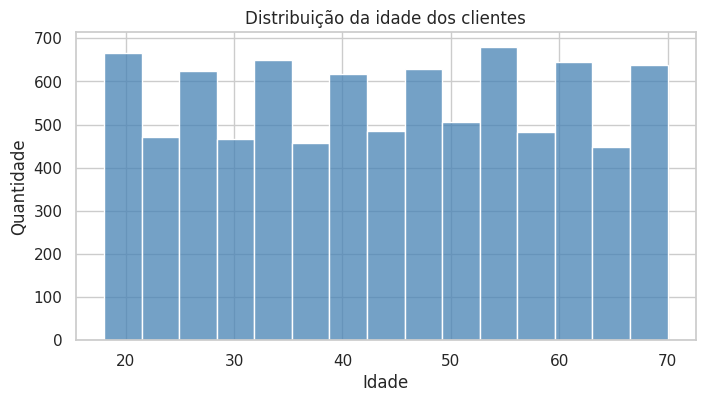

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(dados_limpos["Customer Age"], bins=15, color="steelblue")
plt.title("Distribuição da idade dos clientes")
plt.xlabel("Idade")
plt.ylabel("Quantidade")
plt.show()

`Ticket ID` fica fora da univariada por ser identificador — estatísticas de um contador sequencial não descrevem a população. A segunda variável numérica é `Customer Satisfaction Rating`, disponível apenas para tickets Closed.

,satisfação
count,2769.000000
mean,2.991333
std,1.407016
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000
variancia,1.979694


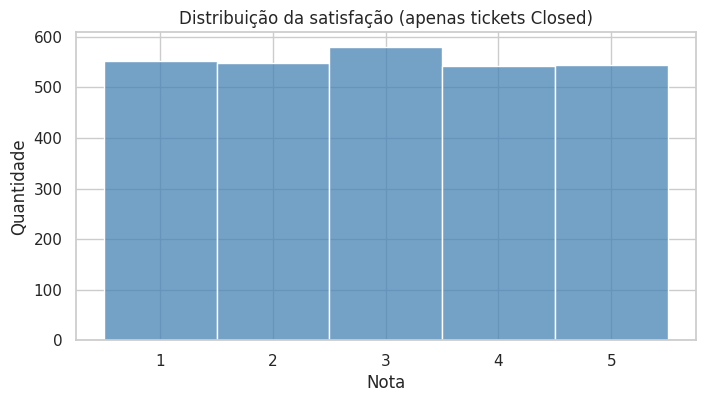

In [13]:
satisfacao = dados_limpos["Customer Satisfaction Rating"].dropna()

estatisticas_satisfacao = satisfacao.describe().to_frame("satisfação")
estatisticas_satisfacao.loc["variancia"] = satisfacao.var()
display(estatisticas_satisfacao)

plt.figure(figsize=(8, 4))
sns.histplot(satisfacao, discrete=True, color="steelblue")
plt.title("Distribuição da satisfação (apenas tickets Closed)")
plt.xlabel("Nota")
plt.ylabel("Quantidade")
plt.show()

A satisfação existe para 2.769 tickets (32,7% — apenas Closed) e é quase uniforme entre as notas 1 e 5 (543 a 580 por nota, média 2,99): não há concentração em notas altas ou baixas, e qualquer análise dela vale só para o subconjunto fechado.

In [14]:
colunas_categoricas = ["Customer Gender", "Product Purchased", "Ticket Type",
                       "Ticket Subject", "Ticket Status", "Ticket Priority", "Ticket Channel"]

resumo_categoricas = pd.DataFrame({
    "categorias": dados_limpos[colunas_categoricas].nunique(),
    "moda": [dados_limpos[c].mode()[0] for c in colunas_categoricas],
    "freq_moda": [dados_limpos[c].value_counts().iloc[0] for c in colunas_categoricas],
    "perc_moda": [round(dados_limpos[c].value_counts(normalize=True).iloc[0] * 100, 2)
                  for c in colunas_categoricas],
})
display(resumo_categoricas)

,categorias,moda,freq_moda,perc_moda
Customer Gender,3,Male,2896,34.20
Product Purchased,42,Canon EOS,240,2.83
Ticket Type,5,Refund request,1752,20.69
Ticket Subject,16,Refund request,576,6.80
Ticket Status,3,Pending Customer Response,2881,34.02
Ticket Priority,4,Medium,2192,25.88
Ticket Channel,4,Email,2143,25.30


In [15]:
def tabela_frequencia(coluna):
    frequencia = dados_limpos[coluna].value_counts()
    percentual = dados_limpos[coluna].value_counts(normalize=True).mul(100).round(2)
    return pd.DataFrame({"frequencia": frequencia, "percentual": percentual})

display(tabela_frequencia("Ticket Type"))
display(tabela_frequencia("Ticket Subject"))
display(tabela_frequencia("Ticket Status"))

,frequencia,percentual
Ticket Type,,
Refund request,1752,20.69
Technical issue,1747,20.63
Cancellation request,1695,20.01
Product inquiry,1641,19.38
Billing inquiry,1634,19.29


,frequencia,percentual
Ticket Subject,,
Refund request,576,6.80
Software bug,574,6.78
Product compatibility,567,6.70
Delivery problem,561,6.62
Hardware issue,547,6.46
Battery life,542,6.40
Network problem,539,6.36
Installation support,530,6.26
Product setup,529,6.25


,frequencia,percentual
Ticket Status,,
Pending Customer Response,2881,34.02
Open,2819,33.29
Closed,2769,32.70


As frequências confirmam a justificativa da escolha do alvo: `Ticket Type` tem 5 classes entre 19,29% e 20,69% (1.634 a 1.752 registros por classe), enquanto `Ticket Subject` tem 16 classes entre 5,64% e 6,80% (478 a 576 registros por classe).

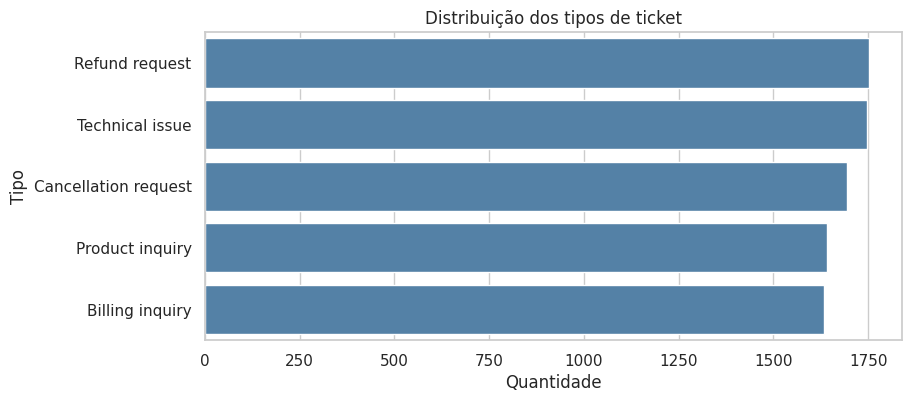

In [16]:
ordem_tipos = dados_limpos["Ticket Type"].value_counts().index

plt.figure(figsize=(9, 4))
sns.countplot(data=dados_limpos, y="Ticket Type", order=ordem_tipos, color="steelblue")
plt.title("Distribuição dos tipos de ticket")
plt.xlabel("Quantidade")
plt.ylabel("Tipo")
plt.show()

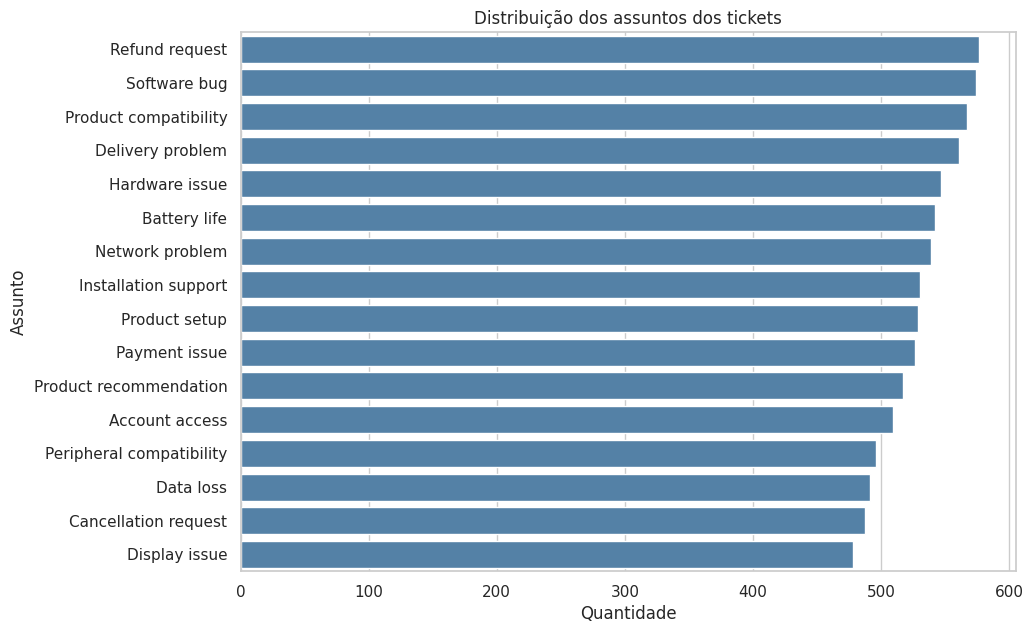

In [17]:
ordem_assuntos = dados_limpos["Ticket Subject"].value_counts().index

plt.figure(figsize=(10, 7))
sns.countplot(data=dados_limpos, y="Ticket Subject", order=ordem_assuntos, color="steelblue")
plt.title("Distribuição dos assuntos dos tickets")
plt.xlabel("Quantidade")
plt.ylabel("Assunto")
plt.show()

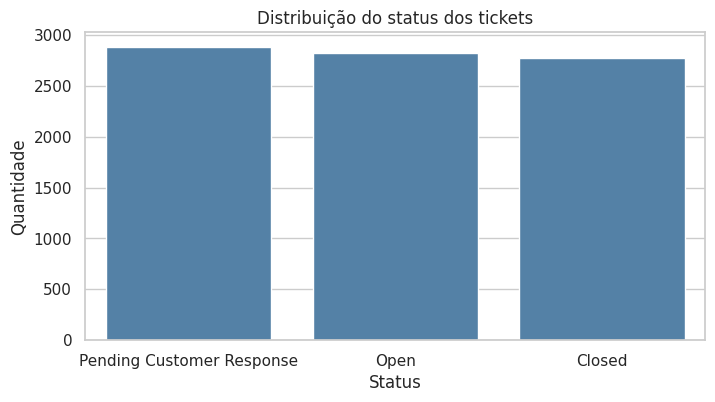

In [18]:
ordem_status = dados_limpos["Ticket Status"].value_counts().index

plt.figure(figsize=(8, 4))
sns.countplot(data=dados_limpos, x="Ticket Status", order=ordem_status, color="steelblue")
plt.title("Distribuição do status dos tickets")
plt.xlabel("Status")
plt.ylabel("Quantidade")
plt.show()

In [19]:
display(tabela_frequencia("Customer Gender"))
display(tabela_frequencia("Ticket Priority"))
display(tabela_frequencia("Ticket Channel"))
display(tabela_frequencia("Product Purchased"))

,frequencia,percentual
Customer Gender,,
Male,2896,34.20
Female,2887,34.09
Other,2686,31.72


,frequencia,percentual
Ticket Priority,,
Medium,2192,25.88
Critical,2129,25.14
High,2085,24.62
Low,2063,24.36


,frequencia,percentual
Ticket Channel,,
Email,2143,25.30
Phone,2132,25.17
Social media,2121,25.04
Chat,2073,24.48


,frequencia,percentual
Product Purchased,,
Canon EOS,240,2.83
GoPro Hero,228,2.69
Nest Thermostat,225,2.66
Philips Hue Lights,221,2.61
Amazon Echo,221,2.61
LG Smart TV,219,2.59
Sony Xperia,217,2.56
Roomba Robot Vacuum,216,2.55
LG OLED,213,2.52


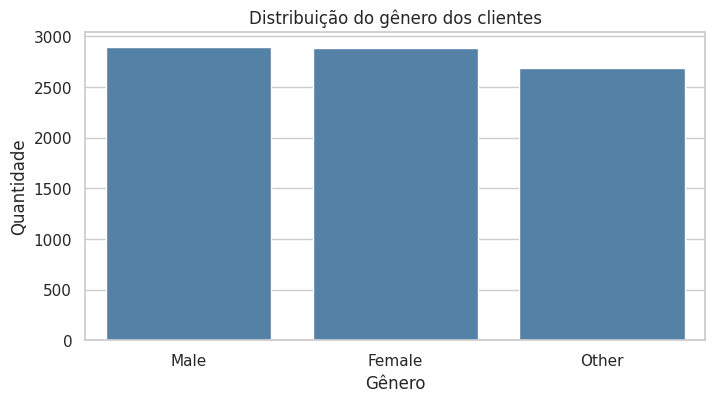

In [20]:
ordem_genero = dados_limpos["Customer Gender"].value_counts().index

plt.figure(figsize=(8, 4))
sns.countplot(data=dados_limpos, x="Customer Gender", order=ordem_genero, color="steelblue")
plt.title("Distribuição do gênero dos clientes")
plt.xlabel("Gênero")
plt.ylabel("Quantidade")
plt.show()

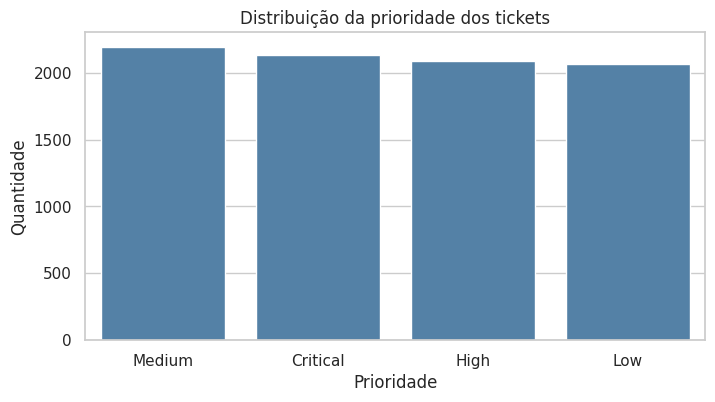

In [21]:
ordem_prioridade = dados_limpos["Ticket Priority"].value_counts().index

plt.figure(figsize=(8, 4))
sns.countplot(data=dados_limpos, x="Ticket Priority", order=ordem_prioridade, color="steelblue")
plt.title("Distribuição da prioridade dos tickets")
plt.xlabel("Prioridade")
plt.ylabel("Quantidade")
plt.show()

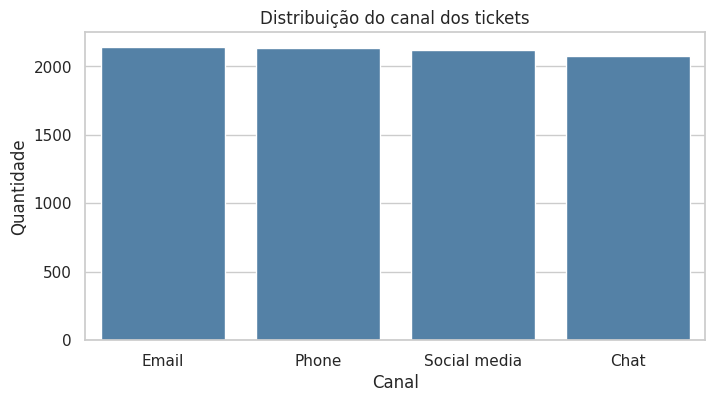

In [22]:
ordem_canal = dados_limpos["Ticket Channel"].value_counts().index

plt.figure(figsize=(8, 4))
sns.countplot(data=dados_limpos, x="Ticket Channel", order=ordem_canal, color="steelblue")
plt.title("Distribuição do canal dos tickets")
plt.xlabel("Canal")
plt.ylabel("Quantidade")
plt.show()

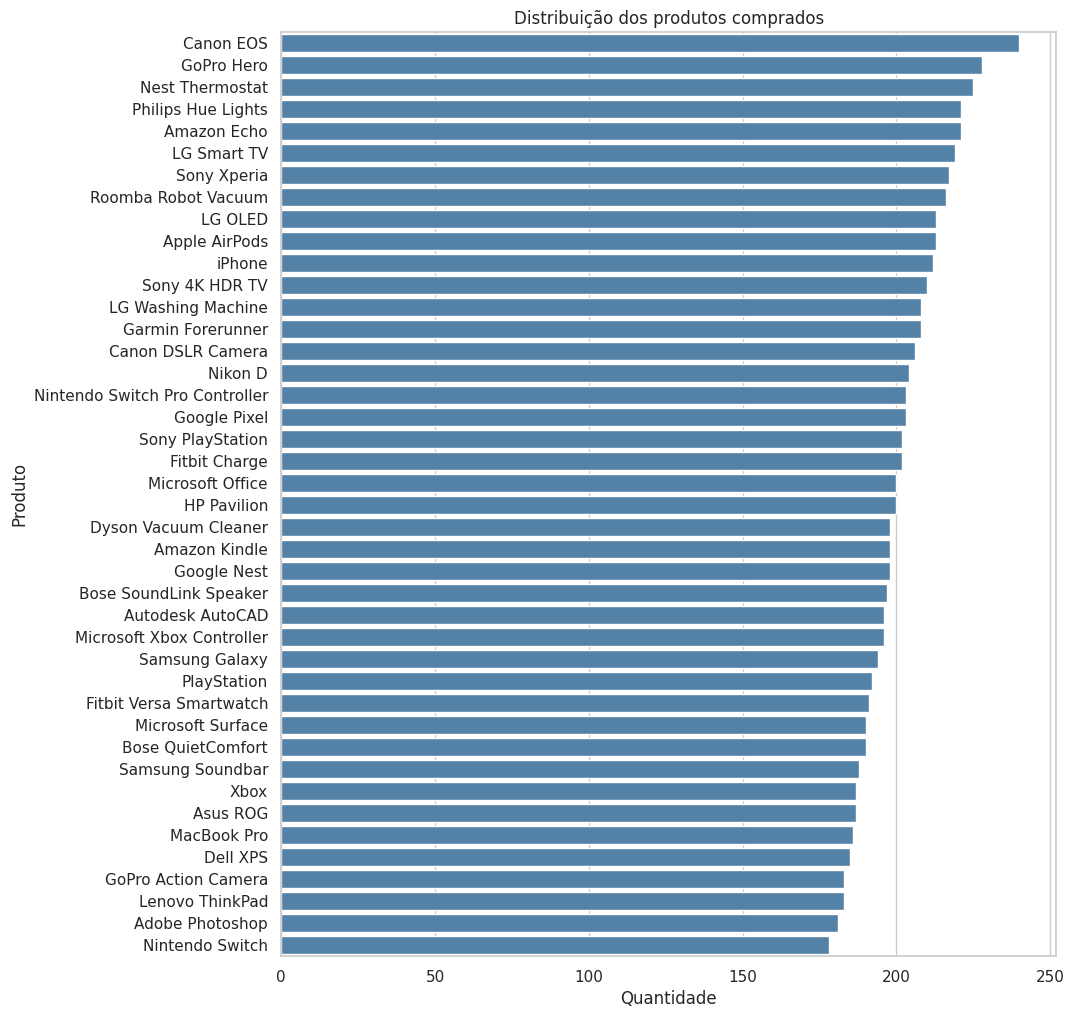

In [23]:
ordem_produtos = dados_limpos["Product Purchased"].value_counts().index

plt.figure(figsize=(10, 12))
sns.countplot(data=dados_limpos, y="Product Purchased", order=ordem_produtos, color="steelblue")
plt.title("Distribuição dos produtos comprados")
plt.xlabel("Quantidade")
plt.ylabel("Produto")
plt.show()

As demais categóricas também são equilibradas: gênero com três categorias entre 31,7% e 34,2%; prioridade (24,4% a 25,9%) e canal (24,5% a 25,3%) com quatro categorias cada; e os 42 produtos aparecem entre 178 e 240 vezes cada. Nenhuma variável categórica tem classe rara ou dominante.

A principal variável textual, `Ticket Description`, é a entrada que a rota `/predict` da API recebe. A univariada adaptada para texto analisa o comprimento das mensagens:

,palavras por descrição
count,8469.000000
mean,48.538907
std,8.619704
min,21.000000
25%,45.000000
50%,51.000000
75%,55.000000
max,67.000000


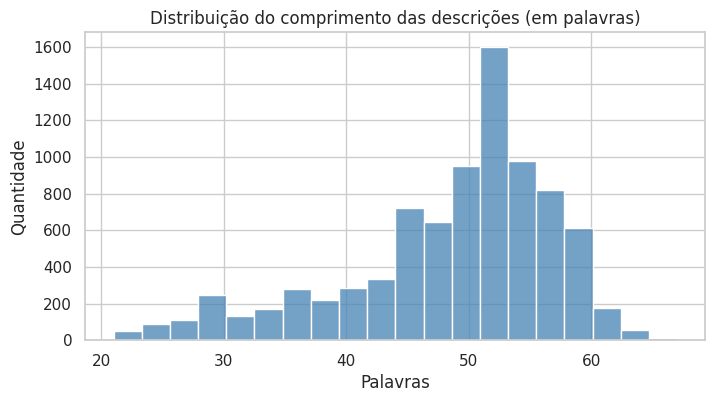

In [24]:
palavras_descricao = dados_limpos["Ticket Description"].str.split().str.len()
display(palavras_descricao.describe().to_frame("palavras por descrição"))

plt.figure(figsize=(8, 4))
sns.histplot(palavras_descricao, bins=20, color="steelblue")
plt.title("Distribuição do comprimento das descrições (em palavras)")
plt.xlabel("Palavras")
plt.ylabel("Quantidade")
plt.show()

As descrições têm entre 21 e 67 palavras (média 48,5), medidas após a substituição do placeholder — ou seja, sobre o texto real que o modelo vai receber: mensagens curtas e de tamanho homogêneo, entrada previsível para as próximas etapas.

## 6. Hipóteses sobre as intenções dos usuários

A partir das frequências e dos gráficos, levantamos três hipóteses:

1. **Desfazer uma transação é a intenção dominante.** As classes Refund request (20,7%) e Cancellation request (20,0%) somam 3.447 tickets — 40,7% do dataset. Nossa hipótese é que a maior demanda do suporte é reverter uma decisão de compra, o que faz destas duas classes as mais críticas para o classificador acertar.
2. **Suporte para usar o produto é o segundo grande grupo.** Technical issue (20,6%) e Product inquiry (19,4%) somam 40,0% dos tickets. Como detalhamento descritivo, os assuntos (`Ticket Subject`) de instalação, configuração e compatibilidade somam 2.122 tickets (25,1% do total) — a hipótese é que boa parte desses usuários está tentando colocar o produto em funcionamento, não relatando defeito.
3. **Nenhuma intenção domina — e isso favorece o modelo.** As 5 classes do alvo ficam entre 19,3% e 20,7%: o sistema precisa discriminar bem todas as classes (não há classe majoritária para "chutar"), mas o equilíbrio dispensa rebalanceamento no treinamento — o que reforça a escolha de `Ticket Type` como alvo feita na seção 1.


## 7. Conclusão

Com a análise inicial, verificamos que o dataset possui 8.469 tickets, não possui registros duplicados e apresenta categorias relativamente equilibradas. Mantivemos os valores ausentes porque eles estão relacionados ao status do atendimento e corrigimos o placeholder encontrado nas descrições.

Os padrões observados indicam intenções ligadas principalmente a reembolso, cancelamento e suporte para configuração ou uso dos produtos. Definimos `Ticket Type` como variável alvo do projeto — 5 classes equilibradas — e `Ticket Description` como principal candidata a feature para o modelo. Esses resultados servem como base para as próximas etapas do projeto.